In [1]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [2]:
iris=load_iris()

In [3]:
x=iris.data
y=iris.target

In [4]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
x.shape

(150, 4)

<Axes: >

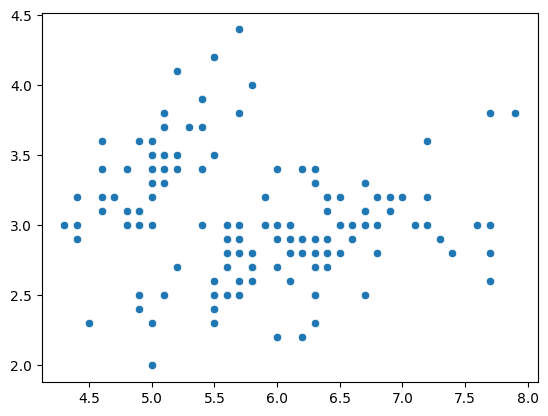

In [6]:
### Visulize
# sns.scatterplot(x=x[:,0],y=x[:,1],c=y)  ### Visulaize datset
sns.scatterplot(x=x[:,0],y=x[:,1])

In [7]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [8]:
### Dimensional reduction using PCA

from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(x_scaled)

In [9]:
### Elbow Method
wscc=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(pca_data)

    wscc.append(kmeans.inertia_)
    

<Axes: >

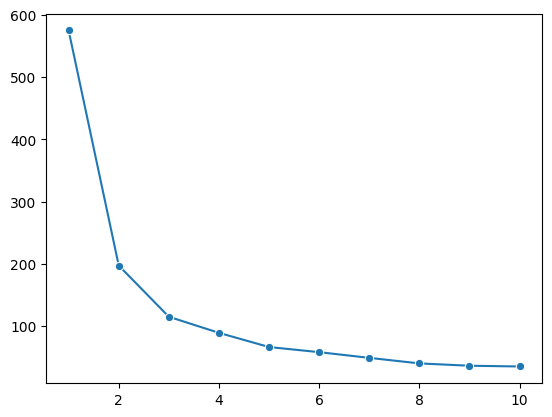

In [10]:
sns.lineplot(x=range(1,11) ,y=wscc, marker='o')

<Axes: >

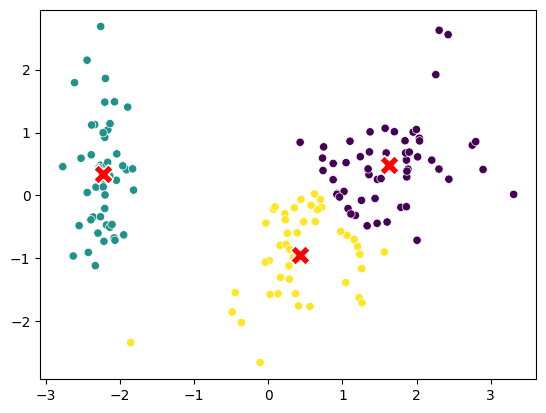

In [17]:
### KMeans

kmeans=KMeans(n_clusters=3,random_state=10)
labels=kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="X",c="red",s=200)